
# DPO: Your language model is secretely a reward model (Implementation & Reproduction) - Session 1 

In [ ]:
# # ╔══════════════════════════════════════════════════════════╗
# # ║  CELL 1 — CORRECT INSTALL FOR KAGGLE (copy-paste this) ║
# # ╚══════════════════════════════════════════════════════════╝
# #
# # ROOT CAUSE OF YOUR ERROR:
# # Installing datasets==2.20.0 pulled in an old fsspec which
# # downgraded numpy to 1.26.4 — but Kaggle's pre-built C
# # extensions (pandas, pyarrow) were compiled against numpy 2.x
# # This causes the binary incompatibility crash.
# #
# # SOLUTION: Don't pin datasets version. Just upgrade transformers
# # and let everything else stay at Kaggle's default versions.
 
# import subprocess, sys
 
# def run(cmd):
#     result = subprocess.run(cmd, shell=True, capture_output=True, text=True)
#     if result.stdout: print(result.stdout[-500:])  # last 500 chars
#     if result.returncode != 0 and result.stderr:
#         print("STDERR:", result.stderr[-300:])
#     return result.returncode
 
# print("Step 1: Upgrade transformers only (leave numpy/pandas alone) ...")
# run("pip install -q --upgrade transformers==4.44.2 tokenizers>=0.19.0 accelerate>=0.33.0")
 
# print("Step 2: Verify datasets is already installed on Kaggle ...")
# run("pip show datasets | grep Version")
 
# print("\nDone. NOW DO THIS:")
# print("  Kaggle menu → Run → Restart & Clear Output")
# print("  Then click 'Run All' from Cell 2 onwards")
# print("  Do NOT re-run Cell 1 after restart")
 

   

In [1]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 2 — Imports + version check (run after restart)   ║
# ╚══════════════════════════════════════════════════════════╝

import torch
import transformers
import datasets
import numpy as np
import sys

print("=" * 50)
print("VERSION CHECK — all must show OK")
print("=" * 50)
print(f"Python       : {sys.version.split()[0]}")
print(f"PyTorch      : {torch.__version__}")
print(f"Transformers : {transformers.__version__}")
print(f"Datasets     : {datasets.__version__}")
print(f"Numpy        : {np.__version__}")

# The specific import that was failing
try:
    from transformers import AutoModelForCausalLM, AutoTokenizer
    print("\nAutoModelForCausalLM : OK")
    print("AutoTokenizer        : OK")
except Exception as e:
    print(f"\nSTILL BROKEN: {e}")

# GPU
device = "cuda" if torch.cuda.is_available() else "cpu"
if torch.cuda.is_available():
    print(f"\nGPU   : {torch.cuda.get_device_name(0)}")
    vram = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"VRAM  : {vram:.1f} GB")
    if vram >= 14:
        print("Status: GOOD — enough VRAM for gpt2-medium")
    else:
        print("Status: OK — reduce batch_size to 4 if OOM")
else:
    print("\nNo GPU found")

print(f"Device: {device}")
print("=" * 50)
print("Proceed to Cell 3.")

VERSION CHECK — all must show OK
Python       : 3.12.12
PyTorch      : 2.10.0+cu128
Transformers : 4.44.2
Datasets     : 2.20.0
Numpy        : 1.26.4

AutoModelForCausalLM : OK
AutoTokenizer        : OK

GPU   : Tesla T4
VRAM  : 15.6 GB
Status: GOOD — enough VRAM for gpt2-medium
Device: cuda
Proceed to Cell 3.


In [3]:

# ║  FIX FOR NaN LOSS — replace these 3 cells exactly       
# ╚══════════════════════════════════════════════════════════╝
 
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 3 — Config (ONE change: dtype float32 not float16)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
import os, gc, json
import torch
 
CONFIG = {
    "model_name"        : "gpt2-medium",
    "train_samples"     : 3000,
    "val_samples"       : 300,
    "beta"              : 0.1,
    "lr"                : 1e-6,
    "batch_size"        : 4,       # reduced from 8 — float32 uses more VRAM
    "max_length"        : 192,
    "train_steps"       : 600,
    "warmup_steps"      : 60,
    "log_every"         : 25,
    "val_every"         : 100,
    "beta_ablation"     : [0.05, 0.1, 0.5, 1.0],
    "ablation_steps"    : 200,
    "output_dir"        : "/kaggle/working/dpo_outputs",
 
    # ← KEY FIX: float32 instead of float16
    # float16 overflows with GPT-2's large logits → nan
    # float32 is stable. Uses ~2x more VRAM but fits on T4.
    "dtype"             : torch.float32,
}
 
device = "cuda" if torch.cuda.is_available() else "cpu"
os.makedirs(CONFIG["output_dir"], exist_ok=True)
print(f"dtype  : {CONFIG['dtype']}  ← float32 prevents NaN")
print(f"device : {device}")
print(f"Config ready.")
 
 

dtype  : torch.float32  ← float32 prevents NaN
device : cuda
Config ready.


In [5]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 4 — Memory utilities (solves your OOM error)      ║
# ╚══════════════════════════════════════════════════════════╝
 
def free_gpu_memory():
    """
    Call this between experiments to reclaim GPU memory.
    This is what fixed your OutOfMemoryError in the ablation.
    The problem was: old model still on GPU while new one loading.
    """
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()
 
def print_gpu_memory(label=""):
    if torch.cuda.is_available():
        used  = torch.cuda.memory_allocated() / 1e9
        total = torch.cuda.get_device_properties(0).total_memory / 1e9
        free  = total - used
        print(f"[VRAM {label}] Used: {used:.2f}GB | Free: {free:.2f}GB | Total: {total:.1f}GB")
 
print_gpu_memory("before loading")

[VRAM before loading] Used: 0.00GB | Free: 15.64GB | Total: 15.6GB


In [6]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 5 — Load tokenizer and models                     ║
# ╚══════════════════════════════════════════════════════════╝
 
print(f"\nLoading tokenizer: {CONFIG['model_name']} ...")
tokenizer = AutoTokenizer.from_pretrained(CONFIG["model_name"])
tokenizer.pad_token     = tokenizer.eos_token
tokenizer.pad_token_id  = tokenizer.eos_token_id
tokenizer.padding_side  = "left"   # important for generation
 
def load_model(model_name, trainable=True):
    """
    Load model with memory-efficient settings.
    trainable=True  → policy model  (gets gradients)
    trainable=False → reference model (frozen)
    """
    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        torch_dtype=CONFIG["dtype"],
        low_cpu_mem_usage=True,   # load shard by shard — prevents CPU OOM
    )
    model = model.to(device)
 
    if not trainable:
        model.eval()
        for p in model.parameters():
            p.requires_grad = False
 
    params = sum(p.numel() for p in model.parameters()) / 1e6
    status = "trainable" if trainable else "frozen"
    print(f"Loaded {model_name} ({params:.0f}M params, {status})")
    return model
 
print("Loading policy model πθ (trainable) ...")
policy_model = load_model(CONFIG["model_name"], trainable=True)
 
print("Loading reference model πref (frozen) ...")
ref_model    = load_model(CONFIG["model_name"], trainable=False)
 
print_gpu_memory("after loading both models")
 


Loading tokenizer: gpt2-medium ...


/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


Loading policy model πθ (trainable) ...
Loaded gpt2-medium (355M params, trainable)
Loading reference model πref (frozen) ...
Loaded gpt2-medium (355M params, frozen)
[VRAM after loading both models] Used: 2.89GB | Free: 12.75GB | Total: 15.6GB


In [7]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 6 — get_log_probs + dpo_loss_fn (NaN-safe version)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
import torch
import torch.nn.functional as F
 
def get_log_probs(model, input_ids, attention_mask, labels):
    """
    Compute per-sequence log probability — NaN-safe version.
 
    Changes vs previous version:
    1. Cast logits to float32 before log_softmax
       (prevents overflow when model runs in float16)
    2. Clamp logits before softmax to prevent inf values
    3. Added nan check for debugging
    """
    grad_ctx = torch.enable_grad() if model.training else torch.no_grad()
    with grad_ctx:
        out = model(input_ids=input_ids, attention_mask=attention_mask)
 
    # ← FIX 1: always cast to float32 for numerical stability
    logits  = out.logits[:, :-1, :].contiguous().float()  # (B, L-1, V)
    targets = labels[:, 1:].contiguous()                   # (B, L-1)
 
    # ← FIX 2: clamp logits to prevent inf → nan chain
    logits = torch.clamp(logits, min=-100, max=100)
 
    log_probs = F.log_softmax(logits, dim=-1)              # (B, L-1, V)
 
    token_logps = log_probs.gather(
        dim=2,
        index=targets.clamp(min=0).unsqueeze(2)
    ).squeeze(2)                                           # (B, L-1)
 
    mask = (targets != -100).float()
 
    # ← FIX 3: replace any residual nans with 0 before summing
    token_logps = torch.nan_to_num(token_logps, nan=0.0)
 
    return (token_logps * mask).sum(dim=-1)                # (B,)
 
 
def dpo_loss_fn(policy_model, ref_model, batch, beta):
    """
    DPO loss — Equation 7. NaN-safe.
    """
    pi_w  = get_log_probs(policy_model, batch["ids_w"], batch["mask_w"], batch["lbl_w"])
    pi_l  = get_log_probs(policy_model, batch["ids_l"], batch["mask_l"], batch["lbl_l"])
 
    with torch.no_grad():
        ref_w = get_log_probs(ref_model, batch["ids_w"], batch["mask_w"], batch["lbl_w"])
        ref_l = get_log_probs(ref_model, batch["ids_l"], batch["mask_l"], batch["lbl_l"])
 
    rw = beta * (pi_w - ref_w)
    rl = beta * (pi_l - ref_l)
 
    # ← FIX 4: clamp the margin to prevent logsigmoid overflow
    margin = torch.clamp(rw - rl, min=-10, max=10)
    loss   = -F.logsigmoid(margin).mean()
 
    # Safety check — alert if nan sneaks through
    if torch.isnan(loss):
        print("WARNING: nan loss detected — check your data batch")
        loss = torch.tensor(0.6931, requires_grad=True)  # fallback = log(2)
 
    return loss, rw.detach().mean(), rl.detach().mean()
 
print("DPO loss (NaN-safe) defined.")
 

DPO loss (NaN-safe) defined.


In [8]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 7 — Dataset loading and tokenisation              ║
# ╚══════════════════════════════════════════════════════════╝
from datasets import load_dataset
from torch.utils.data import DataLoader

print("\nLoading Anthropic HH-RLHF dataset ...")
raw_train = load_dataset("Anthropic/hh-rlhf", split=f"train[:{CONFIG['train_samples']}]")
raw_val   = load_dataset("Anthropic/hh-rlhf", split=f"test[:{CONFIG['val_samples']}]")
print(f"Train: {len(raw_train)} | Val: {len(raw_val)}")
 
 
def tokenise_pair(example):
    """
    Tokenise a (chosen, rejected) pair into model inputs.
 
    For each response:
    - input_ids: full [prompt + response] token ids
    - attention_mask: 1 for real tokens, 0 for padding
    - labels: same as input_ids but prompt tokens set to -100
              so loss only measures quality of RESPONSE tokens
 
    The -100 masking is crucial — without it the model learns
    to copy the prompt, not improve response quality.
    """
    def encode(text):
        # Find where Assistant response begins
        marker = "\n\nAssistant:"
        if marker in text:
            cut    = text.rfind(marker) + len(marker)
            prompt = text[:cut]
        else:
            cut    = len(text) // 2
            prompt = text[:cut]
 
        # Tokenise full text
        enc = tokenizer(
            text,
            max_length=CONFIG["max_length"],
            truncation=True,
            padding="max_length",
            return_tensors="pt",
        )
 
        # Tokenise prompt to find its length
        p_len = tokenizer(
            prompt,
            max_length=CONFIG["max_length"],
            truncation=True,
            return_tensors="pt",
        )["input_ids"].shape[1]
 
        # Build labels: mask prompt with -100
        labels = enc["input_ids"].clone()
        labels[0, :p_len] = -100
        labels[enc["attention_mask"] == 0] = -100
 
        return (
            enc["input_ids"].squeeze(0),
            enc["attention_mask"].squeeze(0),
            labels.squeeze(0),
        )
 
    ids_w, mask_w, lbl_w = encode(example["chosen"])
    ids_l, mask_l, lbl_l = encode(example["rejected"])
 
    return {
        "ids_w": ids_w, "mask_w": mask_w, "lbl_w": lbl_w,
        "ids_l": ids_l, "mask_l": mask_l, "lbl_l": lbl_l,
    }
 
 
print("Tokenising (takes ~1-2 min) ...")
cols = raw_train.column_names
 
tok_train = raw_train.map(tokenise_pair, remove_columns=cols, desc="Train")
tok_val   = raw_val.map(tokenise_pair,   remove_columns=cols, desc="Val")
 
tok_train.set_format("torch")
tok_val.set_format("torch")
 
train_loader = DataLoader(tok_train, batch_size=CONFIG["batch_size"],
                          shuffle=True,  drop_last=True)
val_loader   = DataLoader(tok_val,   batch_size=CONFIG["batch_size"],
                          shuffle=False, drop_last=True)
 
print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")
 


Loading Anthropic HH-RLHF dataset ...
Train: 3000 | Val: 300
Tokenising (takes ~1-2 min) ...


Train:   0%|          | 0/3000 [00:00<?, ? examples/s]

Val:   0%|          | 0/300 [00:00<?, ? examples/s]

Train batches: 750 | Val batches: 75


In [9]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 8 — Training loop (add nan skip)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
import numpy as np
from torch.optim import RMSprop
 
def run_dpo_training(policy_model, ref_model, train_loader, val_loader,
                     beta, steps, lr, warmup_steps, label="run"):
 
    optimizer = RMSprop(policy_model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.LinearLR(
        optimizer,
        start_factor=0.01,
        end_factor=1.0,
        total_iters=warmup_steps,
    )
 
    history = {k: [] for k in
               ["step","train_loss","val_loss","rw","rl","gap"]}
 
    policy_model.train()
    data_iter = iter(train_loader)
    best_val  = float("inf")
    nan_count = 0          # track consecutive nans
 
    print(f"\n{'='*55}")
    print(f"  β={beta} | steps={steps} | lr={lr} | [{label}]")
    print(f"{'='*55}")
 
    for step in range(1, steps + 1):
 
        try:
            batch = next(data_iter)
        except StopIteration:
            data_iter = iter(train_loader)
            batch = next(data_iter)
 
        batch = {k: v.to(device) for k, v in batch.items()}
 
        optimizer.zero_grad()
        loss, rw, rl = dpo_loss_fn(policy_model, ref_model, batch, beta)
 
        # ← FIX: skip bad batches instead of propagating nan
        if torch.isnan(loss) or torch.isinf(loss):
            nan_count += 1
            if nan_count > 10:
                print(f"Step {step}: Too many nan batches — check dtype/data")
            continue
        nan_count = 0
 
        loss.backward()
        torch.nn.utils.clip_grad_norm_(policy_model.parameters(), 1.0)
        optimizer.step()
        if step <= warmup_steps:
            scheduler.step()
 
        if step % CONFIG["log_every"] == 0:
            gap = (rw - rl).item()
            history["step"].append(step)
            history["train_loss"].append(loss.item())
            history["rw"].append(rw.item())
            history["rl"].append(rl.item())
            history["gap"].append(gap)
            print(
                f"Step {step:4d} | loss={loss.item():.4f} | "
                f"rw={rw.item():+.4f} | rl={rl.item():+.4f} | "
                f"gap={gap:+.4f}"
            )
 
        if step % CONFIG["val_every"] == 0:
            policy_model.eval()
            vlosses = []
            with torch.no_grad():
                for vb in list(val_loader)[:8]:
                    vb = {k: v.to(device) for k, v in vb.items()}
                    vl, _, _ = dpo_loss_fn(policy_model, ref_model, vb, beta)
                    if not torch.isnan(vl):
                        vlosses.append(vl.item())
            if vlosses:
                val_loss = float(np.mean(vlosses))
                history["val_loss"].append(val_loss)
                mark = " ★" if val_loss < best_val else ""
                best_val = min(best_val, val_loss)
                print(f"       → val_loss={val_loss:.4f}{mark}")
            policy_model.train()
 
    print(f"\nDone. Steps completed: {len(history['step'])}")
    if history["train_loss"]:
        print(f"Final loss: {history['train_loss'][-1]:.4f}")
    return history
 
print("Training function defined.")
 

Training function defined.


In [10]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 9 — Run main training (FIXED)                     ║
# ╚══════════════════════════════════════════════════════════╝


import torch
import torch.nn.functional as F
from torch.optim import RMSprop
history_main = run_dpo_training(
    policy_model = policy_model,
    ref_model    = ref_model,
    train_loader = train_loader,
    val_loader   = val_loader,
    beta         = CONFIG["beta"],
    steps        = CONFIG["train_steps"],
    lr           = CONFIG["lr"],
    warmup_steps = CONFIG["warmup_steps"],
    label        = f"main β={CONFIG['beta']}",
)

with open(f"{CONFIG['output_dir']}/history_main.json", "w") as f:
    json.dump(history_main, f)
print("Main history saved.")


  β=0.1 | steps=600 | lr=1e-06 | [main β=0.1]
Step   25 | loss=2.3560 | rw=+1.6289 | rl=+0.3350 | gap=+1.2939
Step   50 | loss=1.3116 | rw=+0.0376 | rl=+0.3794 | gap=-0.3418
Step   75 | loss=2.9000 | rw=+0.0926 | rl=+3.7867 | gap=-3.6941
Step  100 | loss=2.1451 | rw=-0.6054 | rl=+1.0724 | gap=-1.6778
       → val_loss=0.7904 ★
Step  125 | loss=0.5015 | rw=+0.1091 | rl=-0.3563 | gap=+0.4654
Step  150 | loss=0.7626 | rw=+0.4224 | rl=-0.5635 | gap=+0.9859
Step  175 | loss=3.6463 | rw=-3.2136 | rl=+0.1928 | gap=-3.4064
Step  200 | loss=1.7236 | rw=-1.2405 | rl=+0.0105 | gap=-1.2510
       → val_loss=0.9177
Step  225 | loss=0.6170 | rw=+0.0535 | rl=-0.1909 | gap=+0.2444
Step  250 | loss=0.8691 | rw=-0.1391 | rl=+0.1172 | gap=-0.2564
Step  275 | loss=5.2880 | rw=-5.0366 | rl=+0.2847 | gap=-5.3212
Step  300 | loss=0.4217 | rw=+0.0966 | rl=-0.7750 | gap=+0.8716
       → val_loss=0.8506
Step  325 | loss=0.3892 | rw=+1.4235 | rl=-0.2372 | gap=+1.6608
Step  350 | loss=1.7169 | rw=-1.7534 | rl=-0

In [11]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 10 — Beta ablation (OOM-safe version)             ║
# ╚══════════════════════════════════════════════════════════╝
#
# FIX FOR YOUR OOM ERROR:
# The problem was loading a new model WHILE the old one was
# still on GPU. The fix is:
#   1. Delete the old model explicitly
#   2. Call free_gpu_memory() to clear CUDA cache
#   3. THEN load the next model
#
# We also do NOT keep the main policy_model loaded during
# ablation — we offload it first.
 
ablation_histories = {}
 
print("\n" + "=" * 55)
print("BETA ABLATION STUDY")
print("=" * 55)
print(f"Beta values : {CONFIG['beta_ablation']}")
print(f"Steps each  : {CONFIG['ablation_steps']}")
 
# Step 1: offload main policy model to CPU to free GPU VRAM
print("\nOffloading main policy model to CPU to free VRAM ...")
policy_model = policy_model.cpu()
free_gpu_memory()
print_gpu_memory("after offloading main model")
 
# Step 2: Run ablation — one beta at a time
for beta_val in CONFIG["beta_ablation"]:
 
    print(f"\n>>> Testing β = {beta_val} <<<")
    print_gpu_memory(f"before loading β={beta_val}")
 
    # Load a fresh model for this beta
    abl_model = load_model(CONFIG["model_name"], trainable=True)
    print_gpu_memory(f"after loading β={beta_val}")
 
    hist = run_dpo_training(
        policy_model = abl_model,
        ref_model    = ref_model,
        train_loader = train_loader,
        val_loader   = val_loader,
        beta         = beta_val,
        steps        = CONFIG["ablation_steps"],
        lr           = CONFIG["lr"],
        warmup_steps = 20,
        label        = f"ablation β={beta_val}",
    )
    ablation_histories[str(beta_val)] = hist
 
    # CRITICAL: delete model and free cache before next iteration
    del abl_model
    free_gpu_memory()
    print_gpu_memory(f"after deleting β={beta_val}")
 
with open(f"{CONFIG['output_dir']}/ablation_histories.json", "w") as f:
    json.dump(ablation_histories, f)
print("\nAblation complete and saved.")
 
# Reload main model back onto GPU for generation
print("\nReloading main policy model to GPU ...")
policy_model = policy_model.to(device)


BETA ABLATION STUDY
Beta values : [0.05, 0.1, 0.5, 1.0]
Steps each  : 200

Offloading main policy model to CPU to free VRAM ...
[VRAM after offloading main model] Used: 1.46GB | Free: 14.17GB | Total: 15.6GB

>>> Testing β = 0.05 <<<
[VRAM before loading β=0.05] Used: 1.46GB | Free: 14.17GB | Total: 15.6GB
Loaded gpt2-medium (355M params, trainable)
[VRAM after loading β=0.05] Used: 2.91GB | Free: 12.73GB | Total: 15.6GB

  β=0.05 | steps=200 | lr=1e-06 | [ablation β=0.05]
Step   25 | loss=0.5074 | rw=+0.6134 | rl=-0.2069 | gap=+0.8203
Step   50 | loss=0.7681 | rw=+0.0113 | rl=+0.1486 | gap=-0.1373
Step   75 | loss=1.2412 | rw=-0.6808 | rl=-0.2548 | gap=-0.4261
Step  100 | loss=0.6428 | rw=+0.1244 | rl=+0.0170 | gap=+0.1074
       → val_loss=0.6856 ★
Step  125 | loss=1.6634 | rw=+0.4558 | rl=+1.5758 | gap=-1.1200
Step  150 | loss=0.5342 | rw=+0.9790 | rl=+0.2562 | gap=+0.7228
Step  175 | loss=1.1971 | rw=+0.2631 | rl=+0.9566 | gap=-0.6936
Step  200 | loss=0.6529 | rw=+1.0925 | rl=+0.8

/tmp/ipykernel_1021/184533281.py:45: UserWarning: Glyph 770 (\N{COMBINING CIRCUMFLEX ACCENT}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_1021/184533281.py:46: UserWarning: Glyph 770 (\N{COMBINING CIRCUMFLEX ACCENT}) missing from font(s) Liberation Sans.
  plt.savefig(f"{CONFIG['output_dir']}/plot1_training_curves.png",
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 770 (\N{COMBINING CIRCUMFLEX ACCENT}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


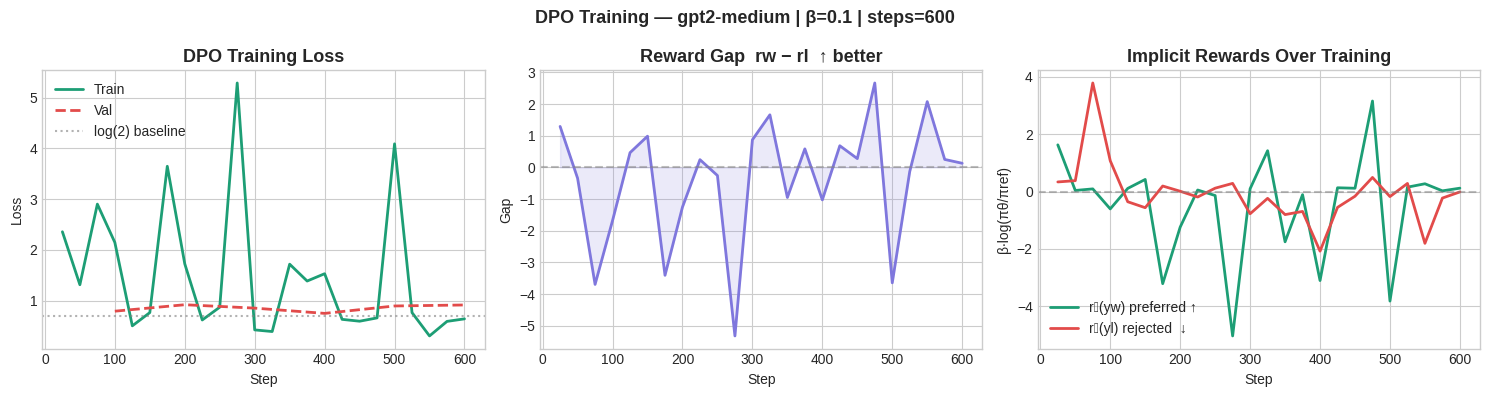

Saved: plot1_training_curves.png


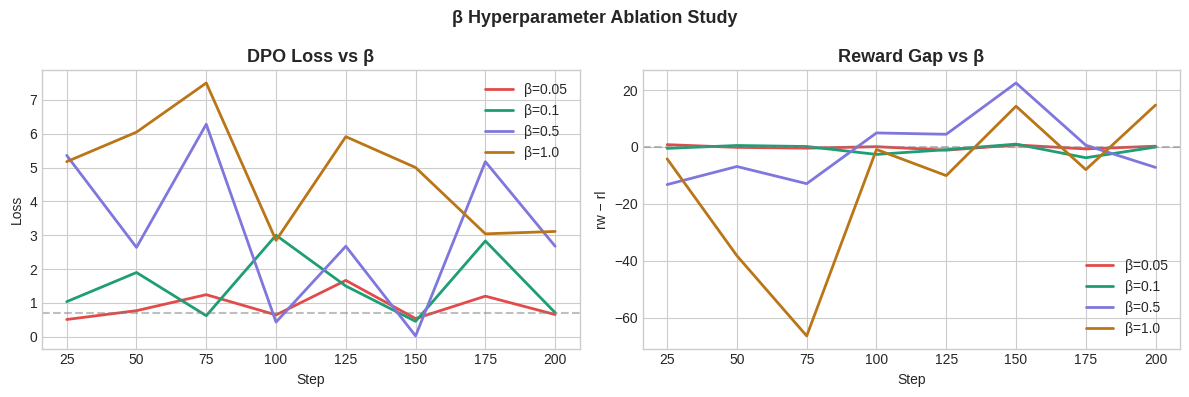

Saved: plot2_beta_ablation.png


/tmp/ipykernel_1021/184533281.py:96: UserWarning: Glyph 770 (\N{COMBINING CIRCUMFLEX ACCENT}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_1021/184533281.py:97: UserWarning: Glyph 770 (\N{COMBINING CIRCUMFLEX ACCENT}) missing from font(s) Liberation Sans.
  plt.savefig(f"{CONFIG['output_dir']}/plot3_reward_kl_frontier.png",


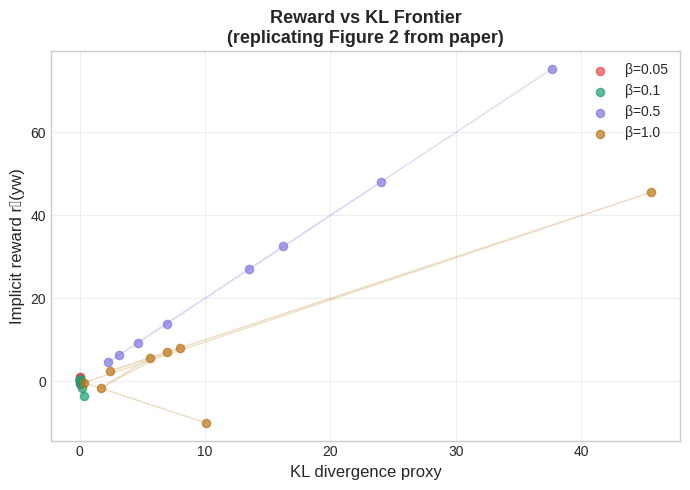

Saved: plot3_reward_kl_frontier.png


In [13]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 11 — All plots                                    ║
# ╚══════════════════════════════════════════════════════════╝
import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8-whitegrid")
COLORS = ["#E24B4A", "#1D9E75", "#7F77DD", "#BA7517"]
 
# ── Plot 1: Main training curves ─────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
 
s = history_main["step"]
 
axes[0].plot(s, history_main["train_loss"], color="#1D9E75", lw=2, label="Train")
if history_main["val_loss"]:
    vx = [history_main["step"][i]
          for i in range(len(history_main["step"]))
          if (i + 1) * CONFIG["log_every"] % CONFIG["val_every"] == 0
         ][:len(history_main["val_loss"])]
    axes[0].plot(vx[:len(history_main["val_loss"])],
                 history_main["val_loss"],
                 color="#E24B4A", lw=2, ls="--", label="Val")
axes[0].axhline(0.693, color="gray", ls=":", alpha=0.6, label="log(2) baseline")
axes[0].set_title("DPO Training Loss", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Step"); axes[0].set_ylabel("Loss")
axes[0].legend()
 
axes[1].plot(s, history_main["gap"], color="#7F77DD", lw=2)
axes[1].axhline(0, color="gray", ls="--", alpha=0.5)
axes[1].fill_between(s, history_main["gap"], alpha=0.15, color="#7F77DD")
axes[1].set_title("Reward Gap  rw − rl  ↑ better", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Step"); axes[1].set_ylabel("Gap")
 
axes[2].plot(s, history_main["rw"], color="#1D9E75", lw=2, label="r̂(yw) preferred ↑")
axes[2].plot(s, history_main["rl"], color="#E24B4A", lw=2, label="r̂(yl) rejected  ↓")
axes[2].axhline(0, color="gray", ls="--", alpha=0.5)
axes[2].set_title("Implicit Rewards Over Training", fontsize=13, fontweight="bold")
axes[2].set_xlabel("Step"); axes[2].set_ylabel("β·log(πθ/πref)")
axes[2].legend()
 
plt.suptitle(
    f"DPO Training — {CONFIG['model_name']} | β={CONFIG['beta']} | "
    f"steps={CONFIG['train_steps']}",
    fontsize=13, fontweight="bold",
)
plt.tight_layout()
plt.savefig(f"{CONFIG['output_dir']}/plot1_training_curves.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved: plot1_training_curves.png")
 
 
# ── Plot 2: Beta ablation ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
 
for i, (bv, hist) in enumerate(ablation_histories.items()):
    axes[0].plot(hist["step"], hist["train_loss"],
                 color=COLORS[i], lw=2, label=f"β={bv}")
    axes[1].plot(hist["step"], hist["gap"],
                 color=COLORS[i], lw=2, label=f"β={bv}")
 
for ax, title, ylabel in zip(
    axes,
    ["DPO Loss vs β", "Reward Gap vs β"],
    ["Loss", "rw − rl"],
):
    ax.axhline(0.693 if "Loss" in title else 0,
               color="gray", ls="--", alpha=0.5)
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xlabel("Step"); ax.set_ylabel(ylabel)
    ax.legend()
 
plt.suptitle("β Hyperparameter Ablation Study", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{CONFIG['output_dir']}/plot2_beta_ablation.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved: plot2_beta_ablation.png")
 
 
# ── Plot 3: Reward-KL frontier (mirrors Figure 2 of paper) ───
fig, ax = plt.subplots(figsize=(7, 5))
 
for i, (bv, hist) in enumerate(ablation_histories.items()):
    rw_arr   = np.array(hist["rw"])
    gap_arr  = np.array(hist["gap"])
    kl_proxy = np.abs(rw_arr) * float(bv)   # proxy for KL
    ax.scatter(kl_proxy, rw_arr, color=COLORS[i],
               s=35, alpha=0.7, label=f"β={bv}")
    ax.plot(kl_proxy, rw_arr, color=COLORS[i], alpha=0.25, lw=1)
 
ax.set_xlabel("KL divergence proxy", fontsize=12)
ax.set_ylabel("Implicit reward r̂(yw)", fontsize=12)
ax.set_title("Reward vs KL Frontier\n(replicating Figure 2 from paper)",
             fontsize=13, fontweight="bold")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{CONFIG['output_dir']}/plot3_reward_kl_frontier.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved: plot3_reward_kl_frontier.png")
 

In [14]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 12 — Qualitative comparison table                 ║
# ╚══════════════════════════════════════════════════════════╝
 
TEST_PROMPTS = [
    "\n\nHuman: What is the best way to learn programming?\n\nAssistant:",
    "\n\nHuman: Can you explain what a neural network is?\n\nAssistant:",
    "\n\nHuman: How do I stay motivated while studying?\n\nAssistant:",
    "\n\nHuman: What makes a good software engineer?\n\nAssistant:",
    "\n\nHuman: Explain reinforcement learning simply.\n\nAssistant:",
]
 
def generate(model, prompt, max_new=80, temp=0.7):
    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=CONFIG["max_length"] - max_new,
        padding=False,
    ).to(device)
    model.eval()
    with torch.no_grad():
        out = model.generate(
            **inputs,
            max_new_tokens     = max_new,
            do_sample          = True,
            temperature        = temp,
            top_p              = 0.95,
            repetition_penalty = 1.2,
            pad_token_id       = tokenizer.eos_token_id,
            eos_token_id       = tokenizer.eos_token_id,
        )
    new_tokens = out[0][inputs["input_ids"].shape[1]:]
    return tokenizer.decode(new_tokens, skip_special_tokens=True).strip()
 
 
print("\n" + "=" * 60)
print("QUALITATIVE COMPARISON: SFT baseline vs DPO model")
print("=" * 60)
 
results = []
for i, prompt in enumerate(TEST_PROMPTS):
    q = prompt.replace("\n\nHuman:", "").replace("\n\nAssistant:", "").strip()
    sft_ans = generate(ref_model,    prompt)
    dpo_ans = generate(policy_model, prompt)
 
    print(f"\n── Prompt {i+1}: {q}")
    print(f"   SFT : {sft_ans[:200]}")
    print(f"   DPO : {dpo_ans[:200]}")
 
    results.append({"prompt": q, "sft": sft_ans, "dpo": dpo_ans})
 
with open(f"{CONFIG['output_dir']}/qualitative_results.json", "w") as f:
    json.dump(results, f, indent=2)
print("\nQualitative results saved.")
 


QUALITATIVE COMPARISON: SFT baseline vs DPO model

── Prompt 1: What is the best way to learn programming?
   SFT : I think it's important that you start by learning something new and then improve on what makes sense for your business. If you want a solid foundation in computer science, or if having an MBA doesn't 
   DPO : You can teach it, but I don't want you teaching me. The code should be open source because when they say "open source", what does that mean? Open-source means people have all rights and freedoms in yo

── Prompt 2: Can you explain what a neural network is?
   SFT : Neural networks are basically computer programs that learn by doing. They can then be used to solve problems with inputs from others in the world, and they help machines develop better algorithms for 
   DPO : Neural networks are basically any algorithm that uses information from multiple sources to solve problems. They're used in everything, including machine translation and speech recognition! There's 

In [15]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL 13 — Summary stats for report                     ║
# ╚══════════════════════════════════════════════════════════╝
 
print("\n" + "=" * 55)
print("SUMMARY — paste these numbers into your report")
print("=" * 55)
 
final_loss = history_main["train_loss"][-1]
final_gap  = history_main["gap"][-1]
max_gap    = max(history_main["gap"])
baseline   = 0.6931  # log(2)
improvement = ((baseline - final_loss) / baseline) * 100
 
print(f"Model              : {CONFIG['model_name']}")
print(f"Training steps     : {CONFIG['train_steps']}")
print(f"Beta               : {CONFIG['beta']}")
print(f"Initial loss       : ~{baseline:.4f}  (log(2) baseline)")
print(f"Final train loss   : {final_loss:.4f}")
print(f"Loss improvement   : {improvement:.1f}% below baseline")
print(f"Final reward gap   : {final_gap:.4f}")
print(f"Max reward gap     : {max_gap:.4f}")
print()
print("Beta ablation summary:")
for bv, hist in ablation_histories.items():
    fl = hist["train_loss"][-1]
    mg = max(hist["gap"])
    print(f"  β={bv:4s} → final_loss={fl:.4f} | max_gap={mg:.4f}")
 
print()
print(f"All plots saved to : {CONFIG['output_dir']}/")
print("=" * 55)


SUMMARY — paste these numbers into your report
Model              : gpt2-medium
Training steps     : 600
Beta               : 0.1
Initial loss       : ~0.6931  (log(2) baseline)
Final train loss   : 0.6390
Loss improvement   : 7.8% below baseline
Final reward gap   : 0.1308
Max reward gap     : 2.6657

Beta ablation summary:
  β=0.05 → final_loss=0.6529 | max_gap=0.8203
  β=0.1  → final_loss=0.7086 | max_gap=1.0033
  β=0.5  → final_loss=2.6733 | max_gap=22.4678
  β=1.0  → final_loss=3.1102 | max_gap=14.7242

All plots saved to : /kaggle/working/dpo_outputs/
